# Ground Reflection and UAV Installation Effects

Notebook 4 established a clean line-of-sight link. This notebook adds the first real installation effects while keeping the geometry deliberately simple:

```text
ground LoRa transmitter -> direct path + one ground reflection -> UAV receiver
```

We will vary the ground material, tilt a dipole on the UAV, and add an illustrative airframe-shadowing correction. Sionna RT calculates propagation and antenna response. It does **not** automatically model motor/ESC electromagnetic interference, receiver desensitization, or LoRa packet decoding; those belong in Notebook 6 and the PHY notebooks, respectively.

This tutorial uses Sionna RT 2.1.0. Its published package pins Mitsuba 3.9.1 and Dr.Jit 1.5.0.


## 1. The two-ray geometry

For flat ground, the reflected path can be found with the image method: mirror the transmitter from height $h_t$ to $-h_t$. For horizontal separation $r$ and UAV height $h_r$,

$$d_0=\sqrt{r^2+(h_r-h_t)^2}, \qquad d_1=\sqrt{r^2+(h_r+h_t)^2}.$$

$d_0$ is the direct distance and $d_1$ is the reflected distance. Their difference creates a phase difference

$$\Delta \phi=\angle\Gamma-2\pi\frac{d_1-d_0}{\lambda},$$

using the propagation convention $e^{-j2\pi d/\lambda}$, where $\Gamma$ is the material- and angle-dependent reflection coefficient. The two paths can reinforce or cancel even when both individual path powers change smoothly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

C = 299_792_458.0
FC_HZ = 2.44e9
BW_HZ = 812_500.0
WAVELENGTH_M = C / FC_HZ
TX_HEIGHT_M = 1.5
UAV_ALTITUDE_M = 30.0
HORIZONTAL_RANGE_M = np.linspace(10.0, 300.0, 241)

direct_distance_m = np.sqrt(HORIZONTAL_RANGE_M**2 + (UAV_ALTITUDE_M - TX_HEIGHT_M)**2)
reflected_distance_m = np.sqrt(HORIZONTAL_RANGE_M**2 + (UAV_ALTITUDE_M + TX_HEIGHT_M)**2)
excess_distance_m = reflected_distance_m - direct_distance_m
excess_delay_s = excess_distance_m / C

assert np.all(reflected_distance_m > direct_distance_m)
assert np.all(np.diff(excess_distance_m) < 0)
print(f"Carrier wavelength: {WAVELENGTH_M:.3f} m")
print(f"LoRa time resolution 1/BW: {1e6 / BW_HZ:.2f} us")
print(f"Two-ray excess delay: {1e9 * excess_delay_s.min():.2f} to {1e9 * excess_delay_s.max():.2f} ns")


Carrier wavelength: 0.123 m
LoRa time resolution 1/BW: 1.23 us
Two-ray excess delay: 1.00 to 9.49 ns


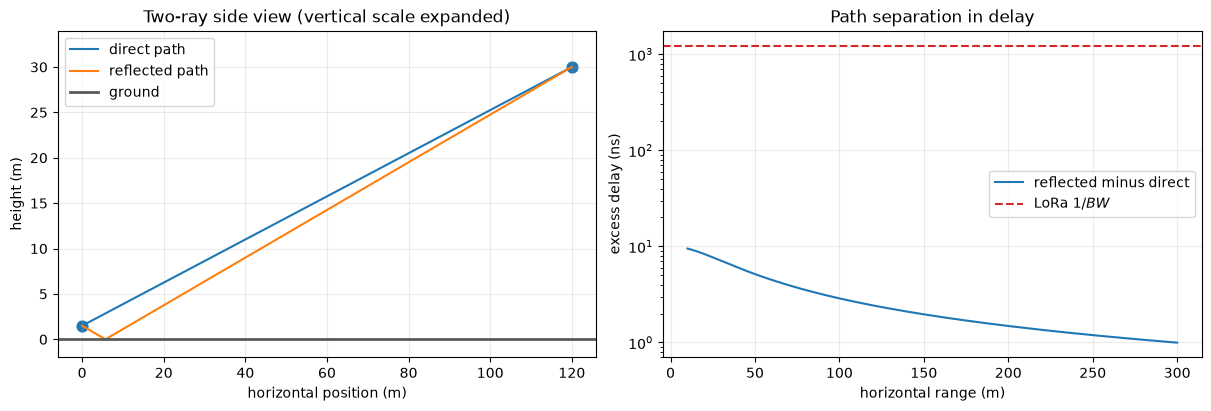

In [2]:
reference_range_m = 120.0
reflection_x_m = reference_range_m * TX_HEIGHT_M / (TX_HEIGHT_M + UAV_ALTITUDE_M)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot([0, reference_range_m], [TX_HEIGHT_M, UAV_ALTITUDE_M], label="direct path")
axes[0].plot([0, reflection_x_m, reference_range_m], [TX_HEIGHT_M, 0, UAV_ALTITUDE_M], label="reflected path")
axes[0].axhline(0, color="0.35", linewidth=2, label="ground")
axes[0].scatter([0, reference_range_m], [TX_HEIGHT_M, UAV_ALTITUDE_M], s=60)
axes[0].set(title="Two-ray side view (vertical scale expanded)", xlabel="horizontal position (m)", ylabel="height (m)", ylim=(-2, 34))
axes[0].legend()

axes[1].plot(HORIZONTAL_RANGE_M, 1e9 * excess_delay_s, label="reflected minus direct")
axes[1].axhline(1e9 / BW_HZ, color="C3", linestyle="--", label=r"LoRa $1/BW$")
axes[1].set(title="Path separation in delay", xlabel="horizontal range (m)", ylabel="excess delay (ns)", yscale="log")
axes[1].legend()
plt.show()


The reflected path is not a separately resolvable LoRa tap here: its excess delay is far below $1/BW$. That does **not** make it irrelevant. The receiver sees the coherent sum of the two complex path coefficients, so a small delay difference can still produce constructive or destructive interference at the 2.44 GHz carrier.


## 2. Put the ground into Sionna RT

The scene is a large flat rectangle. We ask the deterministic path solver for line of sight and one specular reflection only. Each receiver position below is one sample of the same UAV route, not a swarm of UAVs.

The ITU material names are useful hypotheses, not site calibration. Soil moisture, roughness, vegetation, and frequency all affect the real reflection.


In [3]:
from importlib.metadata import version

from sionna.rt import PathSolver, PlanarArray, Receiver, Transmitter, load_scene_from_string

print("Sionna:", version("sionna"))
print("Sionna RT:", version("sionna-rt"))
print("Mitsuba / Dr.Jit:", version("mitsuba"), "/", version("drjit"))

def ground_scene_xml(material):
    return f"""
<scene version="2.1.0">
  <bsdf type="itu-radio-material" id="ground">
    <string name="type" value="{material}"/>
    <float name="thickness" value="0.5"/>
  </bsdf>
  <shape type="rectangle" id="mesh-ground">
    <transform name="to_world">
      <scale x="500" y="500" z="1"/>
    </transform>
    <ref id="ground" name="bsdf"/>
  </shape>
</scene>
"""

def solve_two_ray_route(material, pattern="iso", rx_pitch_deg=0.0):
    scene = load_scene_from_string(ground_scene_xml(material))
    scene.frequency = FC_HZ
    scene.bandwidth = BW_HZ
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern=pattern, polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern=pattern, polarization="V")
    scene.add(Transmitter("ground-tx", position=[0.0, 0.0, TX_HEIGHT_M]))

    pitch_rad = float(np.deg2rad(rx_pitch_deg))
    for index, horizontal_range_m in enumerate(HORIZONTAL_RANGE_M):
        scene.add(Receiver(
            f"uav-rx-{index:03d}",
            position=[float(horizontal_range_m), 0.0, UAV_ALTITUDE_M],
            orientation=[0.0, pitch_rad, 0.0],
        ))

    paths = PathSolver(deterministic=True)(
        scene,
        max_depth=1,
        samples_per_src=32768,
        max_num_paths_per_src=2 * len(HORIZONTAL_RANGE_M),
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=False,
        diffraction=False,
    )
    a, tau = paths.cir(normalize_delays=False, out_type="numpy")
    delays = tau[:, 0, :]
    path_order = np.argsort(np.where(delays >= 0, delays, np.inf), axis=1)
    coefficients = np.take_along_axis(a[:, 0, 0, 0, :, 0], path_order, axis=1)
    delays = np.take_along_axis(delays, path_order, axis=1)
    coherent_gain = np.abs(np.sum(coefficients, axis=-1))**2
    incoherent_gain = np.sum(np.abs(coefficients)**2, axis=-1)
    return {
        "coefficients": coefficients,
        "delay_s": delays,
        "path_gain_db": 10 * np.log10(np.maximum(coherent_gain, 1e-30)),
        "incoherent_gain_db": 10 * np.log10(np.maximum(incoherent_gain, 1e-30)),
    }


Sionna: 2.1.0
Sionna RT: 2.1.0
Mitsuba / Dr.Jit: 3.9.1 / 1.5.0


In [4]:
GROUND_MATERIALS = {
    "very dry ground": "very_dry_ground",
    "medium dry ground": "medium_dry_ground",
    "wet ground": "wet_ground",
}
material_results = {
    label: solve_two_ray_route(material)
    for label, material in GROUND_MATERIALS.items()
}

expected_delays_s = np.column_stack([direct_distance_m, reflected_distance_m]) / C
for label, result in material_results.items():
    actual_delays_s = result["delay_s"]
    assert actual_delays_s.shape == expected_delays_s.shape, f"{label}: unexpected path count"
    assert np.allclose(actual_delays_s[:, 0], expected_delays_s[:, 0], atol=1e-11)
    reflection_present = actual_delays_s[:, 1] >= 0
    assert np.allclose(actual_delays_s[reflection_present, 1], expected_delays_s[reflection_present, 1], atol=1e-11)

free_space_gain_db = -20 * np.log10(4 * np.pi * direct_distance_m / WAVELENGTH_M)
print("Direct and reflected Sionna RT delays match the image-method geometry.")


Direct and reflected Sionna RT delays match the image-method geometry.


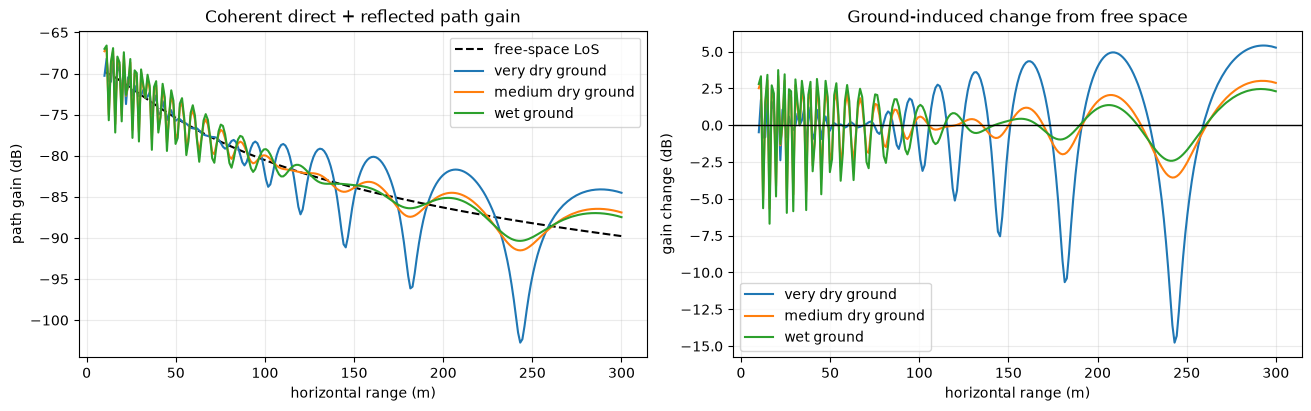

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(HORIZONTAL_RANGE_M, free_space_gain_db, color="black", linestyle="--", label="free-space LoS")
for label, result in material_results.items():
    axes[0].plot(HORIZONTAL_RANGE_M, result["path_gain_db"], label=label)
axes[0].set(title="Coherent direct + reflected path gain", xlabel="horizontal range (m)", ylabel="path gain (dB)")
axes[0].legend()

for label, result in material_results.items():
    axes[1].plot(HORIZONTAL_RANGE_M, result["path_gain_db"] - free_space_gain_db, label=label)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Ground-induced change from free space", xlabel="horizontal range (m)", ylabel="gain change (dB)")
axes[1].legend()
plt.show()


The curves contain peaks and nulls because Sionna adds complex electric fields, not powers. Geometry and wavelength mainly set the fringe spacing; the material-dependent Fresnel coefficient controls the reflected phasor's magnitude and phase, and therefore the fringe contrast and exact null locations. Very dry ground is low-loss and has a pronounced vertical-polarization Brewster region, while conductivity smooths that behavior for wetter ground. Treating the material labels as exact field truth would be overconfident; measured soil conditions and surface roughness should eventually bound or replace them.


### Separate fringe depth from fringe spacing

Normalize the reflected coefficient by the direct coefficient: $a_1/a_0=\rho e^{j\theta}$. Then
$$\frac{|a_0+a_1|^2}{|a_0|^2}=1+\rho^2+2\rho\cos\theta.$$
Deep cancellation requires both comparable amplitudes ($\rho\approx1$) and opposite phases ($\cos\theta\approx-1$). The plots use the actual RT coefficients above, so they help diagnose why one material has deeper or differently shaped oscillations. They do not imply that dry ground always reflects more strongly. For a UAV, a short displacement can cross a narrow fade even at nearly unchanged path loss.

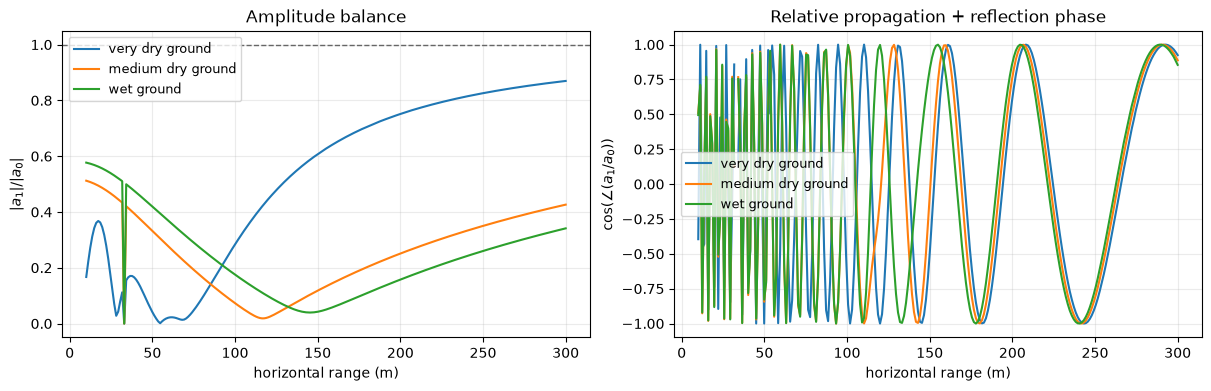

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for label, result in material_results.items():
    a0, a1 = result['coefficients'].T
    ratio = a1 / a0
    rho = np.abs(ratio)
    relative_phase = np.angle(ratio)
    relative_power = 1 + rho**2 + 2 * rho * np.cos(relative_phase)
    assert np.allclose(relative_power, np.abs(a0 + a1)**2 / np.abs(a0)**2, atol=1e-5)
    axes[0].plot(HORIZONTAL_RANGE_M, rho, label=label)
    axes[1].plot(HORIZONTAL_RANGE_M, np.where(rho > 1e-6, np.cos(relative_phase), np.nan), label=label)
axes[0].axhline(1, color='0.4', ls='--', lw=1)
axes[0].set(title='Amplitude balance', xlabel='horizontal range (m)', ylabel=r'$|a_1|/|a_0|$')
axes[1].set(title='Relative propagation + reflection phase', xlabel='horizontal range (m)', ylabel=r'$\cos(\angle(a_1/a_0))$', ylim=(-1.1, 1.1))
for ax in axes:
    ax.legend(fontsize=9)
plt.show()

## 3. See one fade as phasor addition

A receiver does not separately add the powers of two unresolved paths. It first adds their complex amplitudes,

$$h=a_0+a_1, \qquad G=|h|^2.$$

The following plot chooses the deepest sampled fade relative to the free-space baseline for medium-dry ground. The second arrow begins at the tip of the first; the short resultant shows their cancellation.

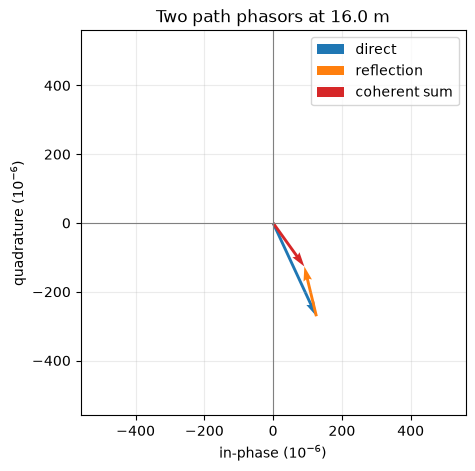

Coherent path gain:   -76.2 dB
Power-only addition: -69.5 dB


In [7]:
medium_result = material_results["medium dry ground"]
fade_index = int(np.argmin(medium_result["path_gain_db"] - free_space_gain_db))
a_direct, a_reflected = medium_result["coefficients"][fade_index]
a_total = a_direct + a_reflected
scale = 1e6

fig, ax = plt.subplots(figsize=(6, 5))
ax.quiver(0, 0, scale * a_direct.real, scale * a_direct.imag, angles="xy", scale_units="xy", scale=1, color="C0", label="direct")
ax.quiver(scale * a_direct.real, scale * a_direct.imag, scale * a_reflected.real, scale * a_reflected.imag, angles="xy", scale_units="xy", scale=1, color="C1", label="reflection")
ax.quiver(0, 0, scale * a_total.real, scale * a_total.imag, angles="xy", scale_units="xy", scale=1, color="C3", label="coherent sum")
extent = 1.25 * scale * (abs(a_direct) + abs(a_reflected))
ax.set(xlim=(-extent, extent), ylim=(-extent, extent), aspect="equal", xlabel=r"in-phase ($10^{-6}$)", ylabel=r"quadrature ($10^{-6}$)", title=f"Two path phasors at {HORIZONTAL_RANGE_M[fade_index]:.1f} m")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.axvline(0, color="0.5", linewidth=0.8)
ax.legend()
plt.show()

print(f"Coherent path gain:   {medium_result['path_gain_db'][fade_index]:.1f} dB")
print(f"Power-only addition: {medium_result['incoherent_gain_db'][fade_index]:.1f} dB")

## 4. Tilt the UAV antenna

Now replace the isotropic antennas with vertical dipoles. Sionna's orientation is $[\alpha,\beta,\gamma]$: rotations about world $z$, then the rotated $y$, then the rotated $x$ axes. We vary only $\beta$ to make a controlled pitch sweep.

This is an antenna-pattern and polarization calculation. It does not yet contain a carbon-fibre frame, battery, landing gear, cable loss, or attitude history from an autopilot.


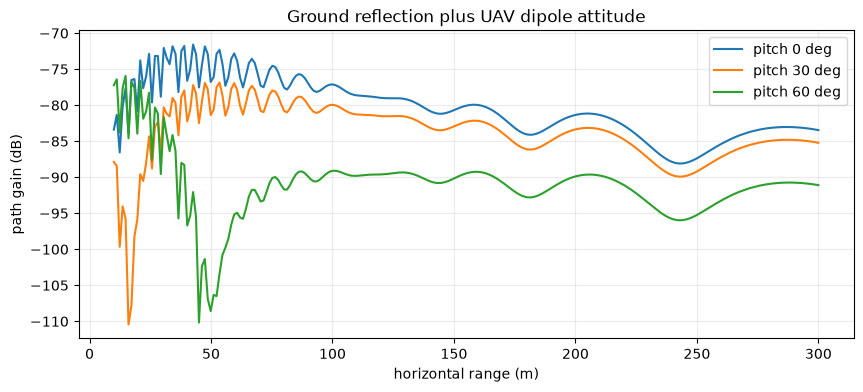

In [8]:
PITCH_CASES_DEG = (0, 30, 60)
attitude_results = {
    pitch_deg: solve_two_ray_route("medium_dry_ground", pattern="dipole", rx_pitch_deg=pitch_deg)
    for pitch_deg in PITCH_CASES_DEG
}

fig, ax = plt.subplots(figsize=(10, 4))
for pitch_deg, result in attitude_results.items():
    ax.plot(HORIZONTAL_RANGE_M, result["path_gain_db"], label=f"pitch {pitch_deg} deg")
ax.set(title="Ground reflection plus UAV dipole attitude", xlabel="horizontal range (m)", ylabel="path gain (dB)")
ax.legend()
plt.show()


Pitch does not create a single constant link-budget penalty. It changes how the antenna responds to both arrival directions and polarizations, so the effect depends on geometry and can reshape the interference pattern. A real flight should supply timestamped roll, pitch, and yaw rather than one fixed angle.


## 5. Add measured airframe shadowing as a separate layer

Sionna RT can model an airframe only if its geometry and radio materials are present, or if its installed antenna pattern is supplied. Until measurements exist, keep any airframe correction visibly separate from the propagation model.

The Gaussian rear notch below is an **illustration**, not a UAV fact. It shows where a measured yaw-sweep table or measured 3D installed pattern would enter the link budget.


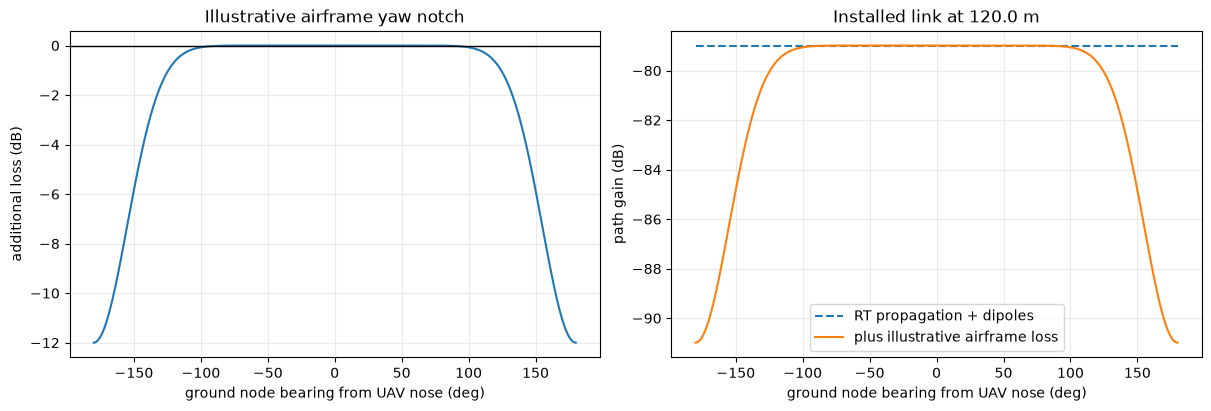

In [9]:
relative_bearing_deg = np.linspace(-180.0, 180.0, 361)

def illustrative_airframe_loss_db(bearing_deg, peak_loss_db=12.0, width_deg=25.0):
    # ponytail: This Gaussian yaw notch is illustrative; replace it with measured installed-pattern data.
    angular_distance_from_tail = 180.0 - np.abs(np.asarray(bearing_deg))
    return -peak_loss_db * np.exp(-0.5 * (angular_distance_from_tail / width_deg)**2)

airframe_loss_db = illustrative_airframe_loss_db(relative_bearing_deg)
reference_index = int(np.argmin(np.abs(HORIZONTAL_RANGE_M - reference_range_m)))
reference_gain_db = attitude_results[0]["path_gain_db"][reference_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(relative_bearing_deg, airframe_loss_db)
axes[0].set(title="Illustrative airframe yaw notch", xlabel="ground node bearing from UAV nose (deg)", ylabel="additional loss (dB)")
axes[0].axhline(0, color="black", linewidth=1)

axes[1].plot(relative_bearing_deg, np.full_like(relative_bearing_deg, reference_gain_db), linestyle="--", label="RT propagation + dipoles")
axes[1].plot(relative_bearing_deg, reference_gain_db + airframe_loss_db, label="plus illustrative airframe loss")
axes[1].set(title=f"Installed link at {HORIZONTAL_RANGE_M[reference_index]:.1f} m", xlabel="ground node bearing from UAV nose (deg)", ylabel="path gain (dB)")
axes[1].legend()
plt.show()


## 6. What this notebook does and does not imply

- **Ground reflection:** direct and reflected fields can cancel even when the paths are too close in delay for LoRa to resolve separately.
- **Material uncertainty:** dry and wet ground hypotheses produce different fades; field measurements must determine which model is credible.
- **Attitude:** UAV pitch changes dipole gain and polarization response for every path, not merely one fixed dB offset.
- **Airframe:** use a measured installed antenna pattern or an explicitly empirical correction. The example notch is not calibrated.
- **No EMI yet:** motor/ESC emissions, onboard digital noise, external LoRa interferers, and Wi-Fi interference require signal/noise models in Notebook 6.
- **No SER/PER claim yet:** path gain and CIR must still feed the LoRa waveform, synchronization, detector, coding, and packet logic from Notebooks 1-3.

A sensible measurement sequence is: dry versus wet ground, level versus commanded attitude, antenna standoff/orientation, then motors off versus on. That ordering helps separate propagation, installation, and electronic interference instead of fitting all unknowns at once.


## Focused references

- Sionna [electromagnetics primer](https://nvlabs.github.io/sionna/rt/em_primer.html): complex field addition, reflection, and polarization. Use it to interpret the two-ray plots, not to infer packet success directly.
- Semtech [SX1261/2 datasheet](../../../ref/semtech-sx1261-sx1262-datasheet-2024.pdf): receiver sensitivity is a device/PHY property; combine it with calibrated propagation and installed antenna measurements.